# Air Quality Prediction in Istanbul  
## Project 3: Classification and Beyond

**Course:** Introduction to Machine Learning YZM2001

**Student:** Berina Juković

**Date:** June 2026

---

### Problem Overview
This project analyzes air quality and weather data from Istanbul to predict whether air conditions are healthy or unhealthy. The dataset contains pollution measurements such as PM10, PM2.5, carbon monoxide, nitrogen dioxide, sulphur dioxide, ozone, and dust, along with weather-related variables such as wind, humidity, and pressure.

In Project 1, the dataset was explored and cleaned. In Project 2, regression models were used to predict PM2.5 concentration. In Project 3, the task is extended into a classification problem by predicting whether the air quality is unhealthy based on the `unhealthy_air` target variable.

### GitHub Repository

You can find the full project repository here:  
https://github.com/bjukovic/Istanbul-Air-Quality-YZM2011-Project-Spring2026

### Selected Track

**Track A – Classification**

This project follows the Classification track. The target variable is `unhealthy_air`, where:

- **0** = Healthy or acceptable air quality
- **1** = Unhealthy air quality

## 1. Recap & Task Definition

### Dataset Summary

The dataset contains historical air quality and weather measurements collected in Istanbul. It includes pollutant concentrations such as PM10, PM2.5, carbon monoxide, nitrogen dioxide, sulphur dioxide, ozone, and dust, together with meteorological variables including temperature, humidity, wind speed, and atmospheric pressure. The objective of the project is to use these environmental factors to predict air quality conditions and identify periods of unhealthy pollution levels.

### Classification Target

The classification target is the **`unhealthy_air`** variable.

* **Class 0 (Healthy Air):** Air quality conditions are considered acceptable and pose little or no risk to public health.
* **Class 1 (Unhealthy Air):** Pollution levels exceed the selected threshold and may negatively affect human health, especially for sensitive groups.

The goal is to train machine learning models that can accurately classify whether a given observation corresponds to healthy or unhealthy air quality conditions.

### Class Distribution

The class distribution is examined to determine whether the dataset is balanced. A balanced dataset contains similar numbers of observations in each class, while an imbalanced dataset may bias the model toward the majority class.

If a significant imbalance is observed, class weighting will be used in applicable models and performance will be evaluated using precision, recall, F1-score, and confusion matrices rather than accuracy alone.

Import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("cleaned_air_quality_weather.csv")

In [3]:
print(df["unhealthy_air"].value_counts())
print(df["unhealthy_air"].value_counts(normalize=True) * 100)

unhealthy_air
0    1413
1    1023
Name: count, dtype: int64
unhealthy_air
0    58.004926
1    41.995074
Name: proportion, dtype: float64


The dataset is reasonably balanced, with healthy air observations representing 58.0% of the data and unhealthy air observations representing 42.0%. Since neither class overwhelmingly dominates the dataset, no special techniques for handling class imbalance were required. Model performance will be evaluated using accuracy, precision, recall, F1-score, and confusion matrices to ensure reliable classification performance across both classes.

In [4]:
class_dist = pd.DataFrame({
    "Count": df["unhealthy_air"].value_counts(),
    "Percentage": df["unhealthy_air"].value_counts(normalize=True) * 100
})

class_dist

,Count,Percentage
unhealthy_air,,
0,1413,58.004926
1,1023,41.995074


## 2. Data Preparation

### Feature Engineering

The feature engineering techniques developed in Project 2 were reused for this classification task and implemented directly in the notebook before splitting the data. These engineered features capture nonlinear relationships, seasonal effects, and interactions between environmental variables that may influence air quality conditions.

The following engineered features were included:

* **pm10_squared** - the squared value of PM10 concentration, used to model potential nonlinear effects of particulate matter.
* **wind_humidity_interaction** - the product of wind speed and humidity, representing the combined influence of weather conditions on pollution dispersion.
* **log_carbon_monoxide** - a logarithmic transformation of carbon monoxide concentration used to reduce skewness.
* **month** - extracted from the date variable to capture seasonal patterns in air quality.
* **day_of_week** - extracted from the date variable to capture weekly trends.

The final feature matrix was defined explicitly instead of using `df.drop("unhealthy_air")`. This avoids direct leakage from `pm2_5`, `us_aqi`, and `european_aqi`, and also excludes non-numeric time/string columns such as `date`, `Condition`, sunrise, sunset, moonrise, and moonset. The same leakage-free feature matrix is used throughout PCA, clustering, model training, tuning, comparison, and error analysis.

### Train, Validation, and Test Split

To ensure consistency with Project 2, the same two-step split strategy was retained: 60% training, 20% validation, and 20% test, using `random_state=42`. Stratification was not used because Project 2 did not use stratified splitting, and the assignment asks for the split to remain consistent with P2.

### Additional Preprocessing

Several machine learning algorithms used in this project, including Logistic Regression, K-Nearest Neighbours, Support Vector Machines, and PCA-based analysis, are sensitive to differences in feature scale. Therefore, numerical features were standardized using `StandardScaler`. The target variable `unhealthy_air` is already encoded as binary values (0 and 1), so no additional target encoding was required.

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Reuse and extend feature engineering from P2
df["date"] = pd.to_datetime(df["date"])
df["month"] = df["date"].dt.month
df["day_of_week"] = df["date"].dt.dayofweek
df["pm10_squared"] = df["pm10"] ** 2
df["wind_humidity_interaction"] = df["AvgWind"] * df["AvgHumidity"]
df["log_carbon_monoxide"] = np.log1p(df["carbon_monoxide"])

features = [
    "pm10",
    "carbon_monoxide",
    "nitrogen_dioxide",
    "sulphur_dioxide",
    "ozone",
    "dust",
    "Rain",
    "MaxTemp",
    "MinTemp",
    "AvgHumidity",
    "AvgWind",
    "AvgPressure",
    "month",
    "day_of_week",
    "pm10_squared",
    "wind_humidity_interaction",
    "log_carbon_monoxide"
]

target = "unhealthy_air"

X = df[features].copy()
y = df[target].astype(int)

# Handle any missing feature values before splitting
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.4,
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    random_state=42
)

train_medians = X_train.median()
X_train_numeric = X_train.fillna(train_medians)
X_val_numeric = X_val.fillna(train_medians)
X_test_numeric = X_test.fillna(train_medians)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_numeric)
X_val_scaled = scaler.transform(X_val_numeric)
X_test_scaled = scaler.transform(X_test_numeric)

print("Training set:", X_train.shape)
print("Validation set:", X_val.shape)
print("Test set:", X_test.shape)

Training set: (1461, 17)
Validation set: (487, 17)
Test set: (488, 17)


## 3. Unsupervised Analysis

Before training supervised classification models, unsupervised learning methods were applied to better understand the internal structure of the dataset. These methods help reveal whether observations naturally form groups and whether those groups are related to the target variable `unhealthy_air`.

To prevent data leakage, all unsupervised models were fitted only on the training data. The validation and test sets were not used during PCA or clustering model fitting.

### 3.1 Dimensionality Reduction with PCA

Principal Component Analysis (PCA) was applied to the scaled training features. PCA transforms the original features into a smaller set of uncorrelated components while preserving as much variance as possible. This helps visualize high-dimensional air quality data in two dimensions and evaluate whether healthy and unhealthy air observations are naturally separable.

In [6]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pca = PCA()
X_train_pca = pca.fit_transform(X_train_scaled)

cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

n_components_90 = np.argmax(cumulative_variance >= 0.90) + 1

print("Number of components needed to explain at least 90% variance:", n_components_90)

Number of components needed to explain at least 90% variance: 9


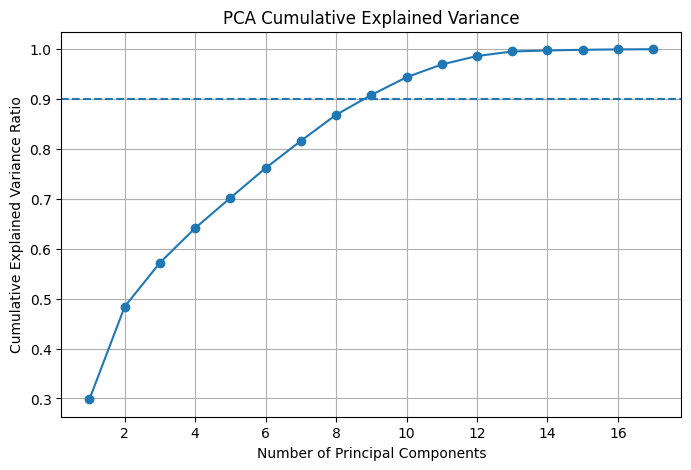

In [7]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker="o")
plt.axhline(y=0.90, linestyle="--")
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance Ratio")
plt.title("PCA Cumulative Explained Variance")
plt.grid(True)
plt.show()

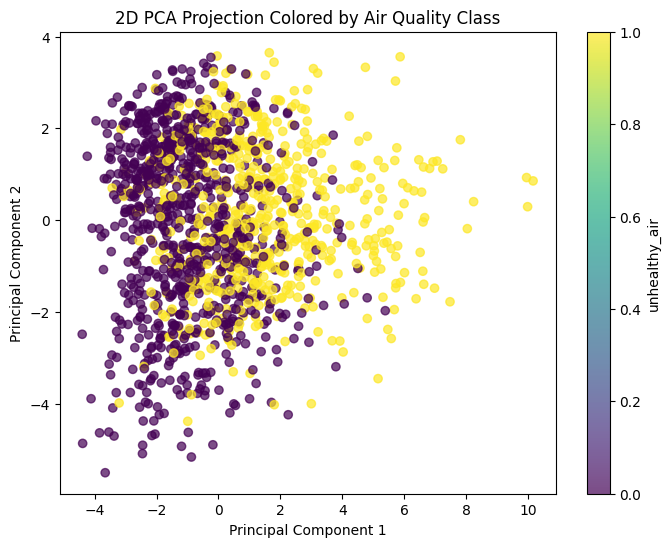

In [8]:
pca_2d = PCA(n_components=2)
X_train_pca_2d = pca_2d.fit_transform(X_train_scaled)

plt.figure(figsize=(8, 6))
plt.scatter(
    X_train_pca_2d[:, 0],
    X_train_pca_2d[:, 1],
    c=y_train,
    alpha=0.7
)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("2D PCA Projection Colored by Air Quality Class")
plt.colorbar(label="unhealthy_air")
plt.show()

### PCA Results and Interpretation

The cumulative explained variance plot shows that **9 principal components** are needed to explain at least **90% of the variance** in the scaled training data. This suggests that the feature space contains some redundancy, but the structure is still moderately high-dimensional because more than only a few components are needed to preserve most of the information.

The two-dimensional PCA projection provides a simplified view of the data using only the first two principal components. The healthy and unhealthy air observations show noticeable overlap, which suggests that the two classes are not clearly separable in a simple two-dimensional linear projection. Some local grouping is visible, but the overlap indicates that classification will likely require models that can use information from more than two dimensions.

Overall, PCA suggests that the dataset contains useful structure, but the first two principal components alone do not fully separate the target classes. Therefore, PCA is useful mainly for visualization and for supporting the clustering analysis, rather than as evidence that the classification task is easy.

Because PCA showed partial overlap between the two classes, clustering was used as a second unsupervised method to examine whether the feature space contains natural groups that are not fully visible in the two-dimensional PCA projection.

### 3.2 Clustering

Clustering techniques were applied to investigate whether the observations naturally form groups without using the target labels. Unlike classification, clustering is an unsupervised learning approach that identifies patterns based solely on feature similarity.

Two clustering algorithms were evaluated:

1. **K-Means Clustering**
2. **Agglomerative Hierarchical Clustering**

The training data was used exclusively for clustering in order to prevent data leakage. Hyperparameters were tuned using clustering quality metrics, including the **Silhouette Score** and the **Davies-Bouldin Index**.

The resulting clusters were visualized in the two-dimensional PCA space and compared against the `unhealthy_air` target variable to determine whether naturally occurring clusters correspond to healthy and unhealthy air quality conditions.

#### K-Means Clustering

K-Means clustering partitions observations into *k* clusters by minimizing the distance between observations and their assigned cluster centroids. The optimal number of clusters was selected using the Elbow Method and Silhouette Score analysis.

The clustering results were evaluated using:

* **Silhouette Score** (higher values indicate better cluster separation)
* **Davies-Bouldin Index** (lower values indicate better cluster quality)

The final cluster assignments were visualized using the first two principal components obtained from PCA.

In [9]:
import warnings
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

warnings.filterwarnings(
    "ignore",
    message="Could not find the number of physical cores.*"
)

silhouette_scores = []
inertias = []

K = range(2, 11)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_train_scaled)
    inertias.append(kmeans.inertia_)
    score = silhouette_score(X_train_scaled, labels)
    silhouette_scores.append(score)

kmeans_tuning = pd.DataFrame({
    "k": list(K),
    "Inertia": inertias,
    "Silhouette Score": silhouette_scores
})

kmeans_tuning

,k,Inertia,Silhouette Score
0,2,20079.747630,0.203367
1,3,17319.883700,0.179967
2,4,15983.633341,0.166795
3,5,15124.629794,0.137778
4,6,14356.301242,0.148254
5,7,13551.137228,0.152143
6,8,12947.139818,0.146278
7,9,12311.562195,0.152337
8,10,11908.020287,0.132327


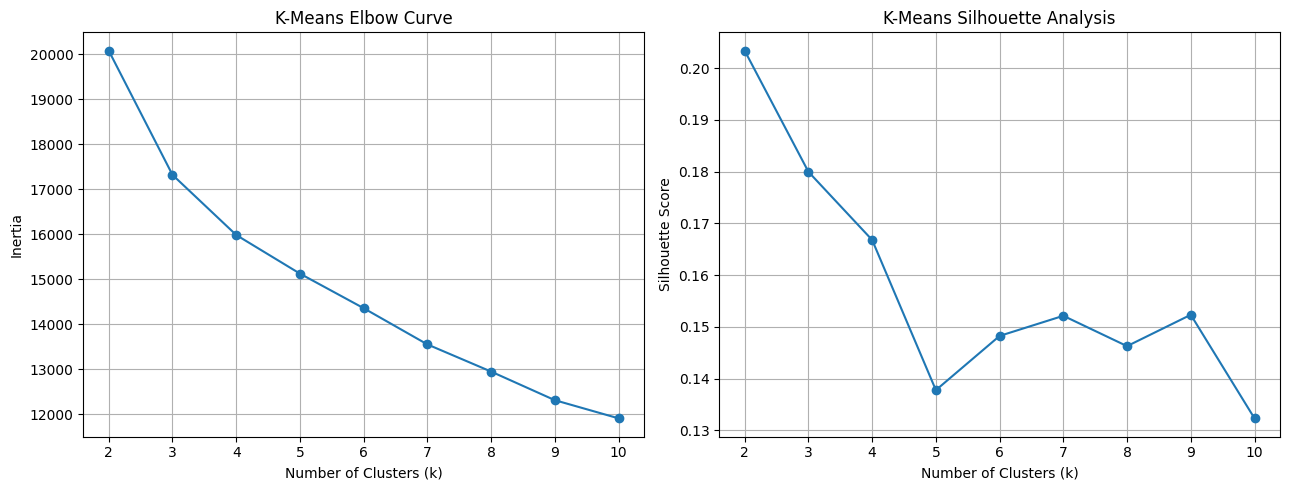

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(K, inertias, marker="o")
axes[0].set_xlabel("Number of Clusters (k)")
axes[0].set_ylabel("Inertia")
axes[0].set_title("K-Means Elbow Curve")
axes[0].grid(True)

axes[1].plot(K, silhouette_scores, marker="o")
axes[1].set_xlabel("Number of Clusters (k)")
axes[1].set_ylabel("Silhouette Score")
axes[1].set_title("K-Means Silhouette Analysis")
axes[1].grid(True)

plt.tight_layout()
plt.show()

##### K-Means Results

The number of clusters was selected using both the Elbow Method and Silhouette Score analysis. Values of *k* from 2 to 10 were evaluated. The elbow curve shows how inertia decreases as more clusters are added, while the Silhouette Score measures how clearly separated the resulting clusters are.

Based on the Elbow curve and Silhouette analysis, **k = 2** was selected as a reasonable K-Means solution. The Silhouette Score is modest, which indicates that the clusters are not strongly separated. Therefore, the K-Means result should be interpreted as evidence of some broad structure in the training data, not as proof of two naturally distinct air-quality groups.

The fact that **k = 2** also matches the binary classification target makes the solution easy to compare with `unhealthy_air`, but the cluster choice was evaluated using unsupervised criteria rather than target labels.

In [11]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score

kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)

kmeans_labels = kmeans.fit_predict(X_train_scaled)

sil_score = silhouette_score(X_train_scaled, kmeans_labels)
db_score = davies_bouldin_score(X_train_scaled, kmeans_labels)

print("Silhouette Score:", sil_score)
print("Davies-Bouldin Index:", db_score)

Silhouette Score: 0.20336739060039957
Davies-Bouldin Index: 1.8769280828711534


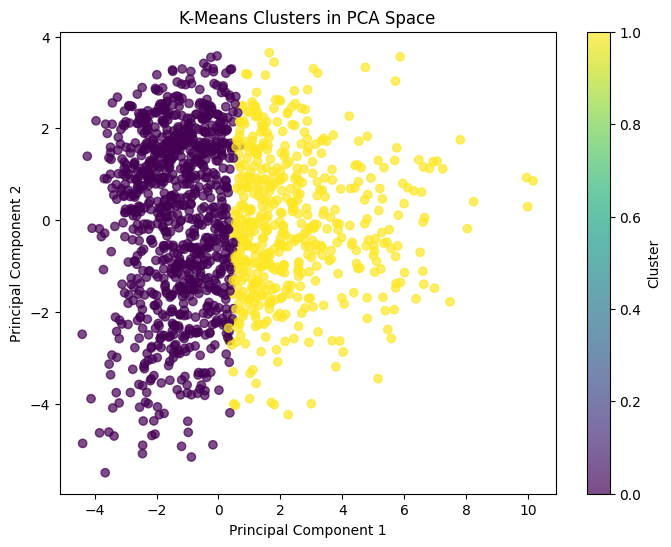

In [12]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_train_pca_2d[:,0],
    X_train_pca_2d[:,1],
    c=kmeans_labels,
    alpha=0.7
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("K-Means Clusters in PCA Space")
plt.colorbar(label="Cluster")
plt.show()

The final K-Means model with **k = 2** is evaluated using Silhouette Score and Davies-Bouldin Index in the code above.

The Silhouette Score indicates how separated the clusters are, while the Davies-Bouldin Index measures compactness and overlap. Together, these metrics help determine whether the observations contain useful natural grouping. Even when the scores are moderate, the resulting clusters may still provide useful structure for later comparison with the supervised target.

In [13]:
pd.crosstab(
    kmeans_labels,
    y_train,
    normalize="index"
) * 100

unhealthy_air,0,1
row_0,,
0,76.602564,23.397436
1,27.238095,72.761905


##### Cluster Alignment with Target Labels

To evaluate whether the discovered clusters correspond to the target variable, cluster assignments were compared with the `unhealthy_air` labels using the cross-tabulation above.

The K-Means cross-tabulation shows that the clusters have some relationship with the target labels, but they are not perfectly aligned. One cluster contains a larger proportion of unhealthy-air observations, while the other contains a larger proportion of healthy-air observations. This suggests that the clustering captures air-quality-related structure, but it does not reproduce the supervised target exactly.

This is expected because clustering uses only feature similarity and does not know the class labels during fitting. If both target classes are mixed within each cluster, then clustering may be capturing environmental structure that is related to the features but not directly equivalent to the healthy/unhealthy label.

#### Agglomerative Hierarchical Clustering

Agglomerative Hierarchical Clustering was applied as a second clustering approach. Unlike K-Means, which partitions observations around centroids, hierarchical clustering progressively merges similar observations into larger groups. Different linkage criteria were evaluated to determine which structure best represents the data.

The resulting clusters were assessed using the same evaluation metrics as K-Means, namely the Silhouette Score and Davies-Bouldin Index, and visualized in PCA space for comparison.

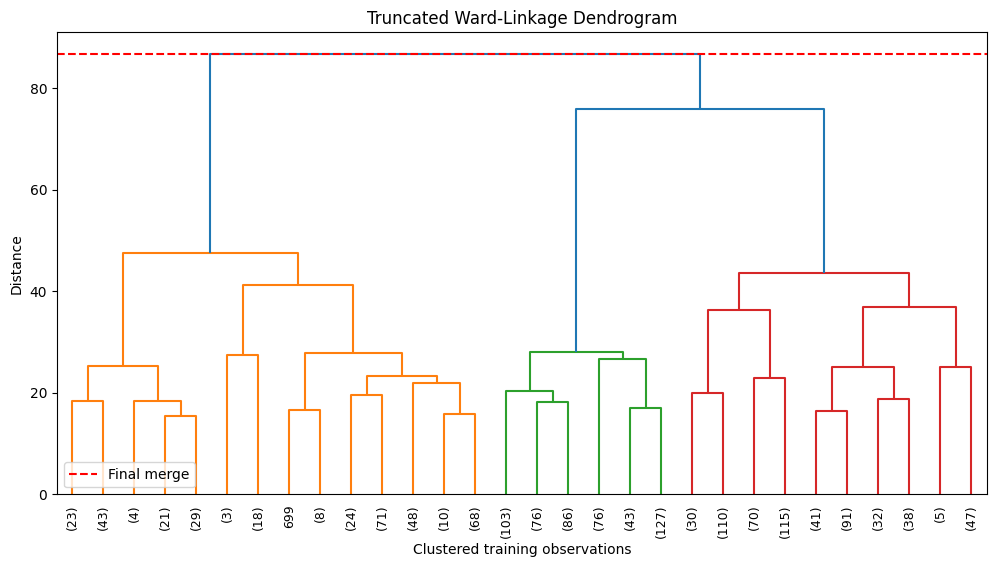

In [14]:
from scipy.cluster.hierarchy import linkage, dendrogram

ward_linkage = linkage(X_train_scaled, method="ward")

plt.figure(figsize=(12, 6))
dendrogram(
    ward_linkage,
    truncate_mode="lastp",
    p=30,
    leaf_rotation=90,
    leaf_font_size=9
)
plt.title("Truncated Ward-Linkage Dendrogram")
plt.xlabel("Clustered training observations")
plt.ylabel("Distance")
plt.axhline(y=ward_linkage[-1, 2], color="red", linestyle="--", label="Final merge")
plt.legend()
plt.show()

In [15]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score

agg_records = []
agg_labels_by_linkage = {}

for linkage in ["ward", "complete", "average", "single"]:
    agg = AgglomerativeClustering(
        n_clusters=2,
        linkage=linkage
    )

    labels = agg.fit_predict(X_train_scaled)
    agg_labels_by_linkage[linkage] = labels

    counts = pd.Series(labels).value_counts().sort_index()
    sil = silhouette_score(X_train_scaled, labels)
    db = davies_bouldin_score(X_train_scaled, labels)

    agg_records.append({
        "Linkage": linkage,
        "Silhouette Score": sil,
        "Davies-Bouldin Index": db,
        "Smallest Cluster Count": counts.min(),
        "Smallest Cluster %": counts.min() / len(labels) * 100
    })

agg_results = pd.DataFrame(agg_records).sort_values(
    ["Silhouette Score", "Davies-Bouldin Index"],
    ascending=[False, True]
)

# Avoid selecting a linkage only because it isolates a very small outlier cluster
meaningful_agg_results = agg_results[agg_results["Smallest Cluster %"] >= 5]
if len(meaningful_agg_results) > 0:
    best_agg_linkage = meaningful_agg_results.iloc[0]["Linkage"]
else:
    best_agg_linkage = agg_results.iloc[0]["Linkage"]

best_agg_labels = agg_labels_by_linkage[best_agg_linkage]

print("Agglomerative clustering tuning results:")
display(agg_results)
print("Selected linkage:", best_agg_linkage)

Agglomerative clustering tuning results:


,Linkage,Silhouette Score,Davies-Bouldin Index,Smallest Cluster Count,Smallest Cluster %
1,complete,0.68907,0.492149,3,0.205339
2,average,0.68907,0.492149,3,0.205339
3,single,0.68388,0.226735,1,0.068446
0,ward,0.19485,2.007039,371,25.393566


Selected linkage: ward


##### Agglomerative Clustering Results

Four linkage criteria were evaluated for Agglomerative Hierarchical Clustering: ward, complete, average, and single linkage. Although single linkage can sometimes produce a high Silhouette Score and low Davies-Bouldin Index, it is especially vulnerable to the chaining effect, where points are connected through narrow chains rather than forming compact, meaningful clusters. For this reason, the linkage methods were not compared using Silhouette Score and Davies-Bouldin Index alone; the size of the smallest cluster was also checked.

In this analysis, linkage methods that produced extremely small clusters should be interpreted cautiously, even if their metric values appear strong. A solution that isolates only one or a few observations may reflect outliers rather than a useful grouping of the dataset. Therefore, the selected Agglomerative result should be described as the most reasonable clustering configuration among those tested, not as definitively the best clustering method.

The selected Agglomerative model is visualized below in PCA space and compared with the target labels to evaluate whether its clusters align with healthy and unhealthy air quality observations.

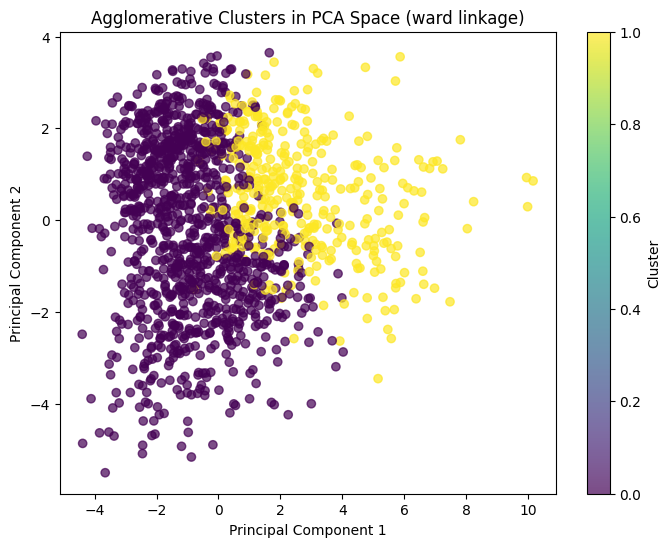

unhealthy_air,0,1
row_0,,
0,71.834862,28.165138
1,20.754717,79.245283


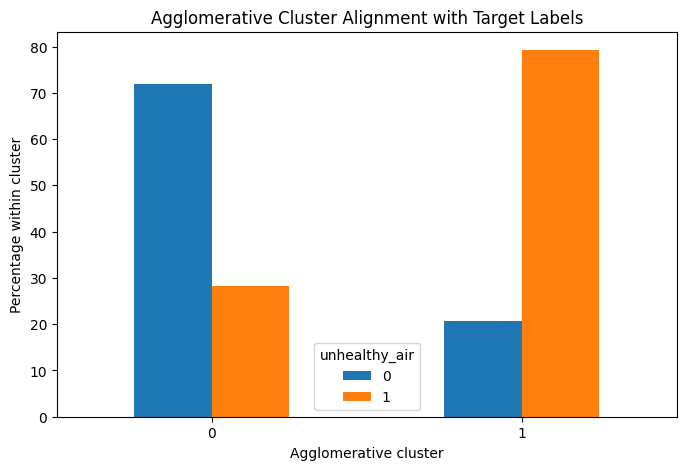

In [16]:
plt.figure(figsize=(8, 6))
plt.scatter(
    X_train_pca_2d[:, 0],
    X_train_pca_2d[:, 1],
    c=best_agg_labels,
    alpha=0.7
)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title(f"Agglomerative Clusters in PCA Space ({best_agg_linkage} linkage)")
plt.colorbar(label="Cluster")
plt.show()

agg_target_alignment = pd.crosstab(
    best_agg_labels,
    y_train,
    normalize="index"
) * 100

display(agg_target_alignment)

agg_target_alignment.plot(kind="bar", figsize=(8, 5))
plt.ylabel("Percentage within cluster")
plt.xlabel("Agglomerative cluster")
plt.title("Agglomerative Cluster Alignment with Target Labels")
plt.legend(title="unhealthy_air")
plt.xticks(rotation=0)
plt.show()

### Comparison of Clustering Methods

K-Means and Agglomerative Clustering provided complementary views of the training data structure. K-Means produced a simple centroid-based partition that can be applied to validation and test observations using `.predict()`, making it practical for feature engineering. Agglomerative Clustering was useful for comparing hierarchical structure across linkage methods, but some linkage choices can be sensitive to outliers or chaining effects.

For this reason, the clustering results are interpreted as exploratory evidence rather than definitive class discovery. The cluster assignments are compared with the target labels to assess alignment, but supervised model performance is still needed to determine whether cluster membership adds predictive value.

### 3.3 Cluster Labels as a Feature

The cluster assignments generated by the final K-Means model were incorporated into the supervised learning pipeline as an additional engineered feature. K-Means was used for this step because it can assign cluster labels to the training, validation, and test sets after being fitted on the training data only.

A simple Logistic Regression model is trained with and without the cluster label to test whether this engineered feature improves validation performance. The result is interpreted after the comparison table.

In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score

best_kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
best_kmeans.fit(X_train_scaled)

train_clusters = best_kmeans.predict(X_train_scaled)
val_clusters = best_kmeans.predict(X_val_scaled)
test_clusters = best_kmeans.predict(X_test_scaled)

X_train_with_cluster = np.column_stack([X_train_scaled, train_clusters])
X_val_with_cluster = np.column_stack([X_val_scaled, val_clusters])
X_test_with_cluster = np.column_stack([X_test_scaled, test_clusters])

baseline_clf = LogisticRegression(max_iter=1000, random_state=42)
baseline_clf.fit(X_train_scaled, y_train)
baseline_val_pred = baseline_clf.predict(X_val_scaled)

cluster_clf = LogisticRegression(max_iter=1000, random_state=42)
cluster_clf.fit(X_train_with_cluster, y_train)
cluster_val_pred = cluster_clf.predict(X_val_with_cluster)

cluster_feature_results = pd.DataFrame([
    {
        "Model Version": "Without cluster label",
        "Validation Accuracy": accuracy_score(y_val, baseline_val_pred),
        "Validation F1 (macro)": f1_score(y_val, baseline_val_pred, average="macro")
    },
    {
        "Model Version": "With K-Means cluster label",
        "Validation Accuracy": accuracy_score(y_val, cluster_val_pred),
        "Validation F1 (macro)": f1_score(y_val, cluster_val_pred, average="macro")
    }
])

cluster_feature_results["F1 Difference vs Baseline"] = (
    cluster_feature_results["Validation F1 (macro)"]
    - cluster_feature_results.loc[0, "Validation F1 (macro)"]
)

cluster_feature_results

,Model Version,Validation Accuracy,Validation F1 (macro),F1 Difference vs Baseline
0,Without cluster label,0.843943,0.839039,0.000000
1,With K-Means cluster label,0.841889,0.836800,-0.002239


The cluster-label experiment shows whether the unsupervised grouping adds information beyond the original scaled numerical features. In this run, the validation macro F1-score does not improve after adding the K-Means cluster label, so the cluster assignment is more useful for exploratory analysis than for improving this Logistic Regression baseline.

### 3.4 Summary of Unsupervised Analysis

The unsupervised analysis showed that the air-quality dataset contains some structure, but the separation between healthy and unhealthy observations is not complete. PCA indicated that 9 components are needed to explain at least 90% of the variance, and the two-dimensional PCA projection showed overlap between the target classes. This suggests that the classification problem cannot be fully explained by only the first two principal components.

K-Means and Agglomerative Clustering both found groupings that had some relationship with the `unhealthy_air` target, but the clusters should not be interpreted as exact substitutes for the class labels. In particular, Agglomerative results must be interpreted carefully because linkage choices such as single linkage can be affected by chaining and outlier-sensitive cluster formation.

Finally, adding the K-Means cluster label as an engineered feature slightly decreased validation macro F1 in the Logistic Regression comparison. Therefore, the main value of the unsupervised analysis is exploratory: it helps describe the structure of the feature space and supports later supervised modelling, but it does not by itself prove strong class separability or improve classification performance.

## 4. Model Training

After completing the unsupervised analysis, supervised classification models were trained to predict whether air quality conditions are healthy or unhealthy. A diverse set of models was selected to represent different machine learning approaches, including linear, distance-based, tree-based, kernel-based, and ensemble methods.

The following six classification algorithms were evaluated:

1. Logistic Regression
2. K-Nearest Neighbours (KNN)
3. Decision Tree
4. Support Vector Machine (SVM)
5. Random Forest
6. Gradient Boosting

This satisfies the requirement to train at least four models and includes two ensemble methods: **Random Forest** and **Gradient Boosting**. Each model was trained using the training set and evaluated on the validation set. Performance was measured using validation accuracy, macro precision, macro recall, and macro-averaged F1-score. Confusion matrices were also generated to visualize classification performance and identify patterns of misclassification.

The objective of this stage is to establish baseline validation performance before systematic hyperparameter tuning is performed in the next section.


Logistic Regression
Validation Accuracy       : 0.8439
Validation Precision Macro: 0.8501
Validation Recall Macro   : 0.8349
Validation F1 Macro       : 0.8390


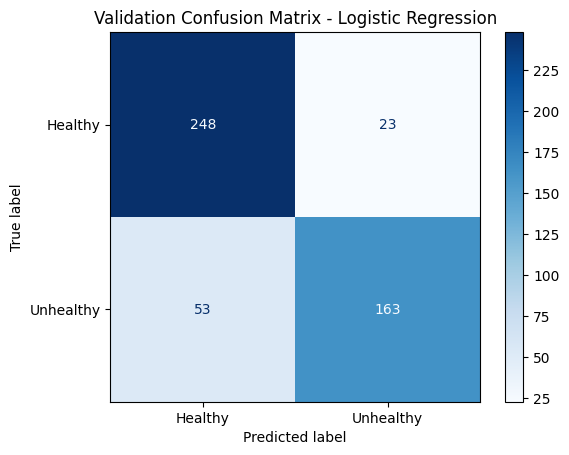


KNN
Validation Accuracy       : 0.8193
Validation Precision Macro: 0.8194
Validation Recall Macro   : 0.8132
Validation F1 Macro       : 0.8154


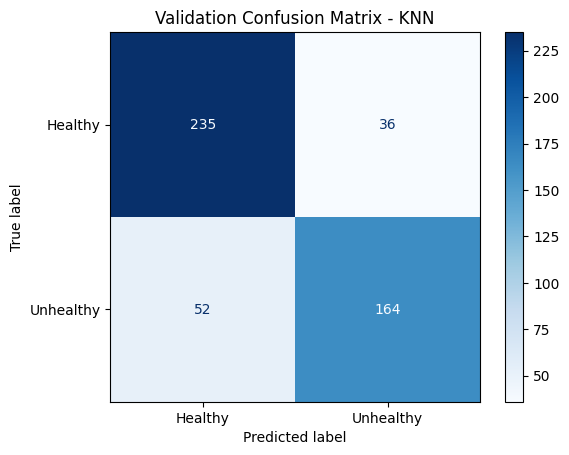


Decision Tree
Validation Accuracy       : 0.7885
Validation Precision Macro: 0.7862
Validation Recall Macro   : 0.7841
Validation F1 Macro       : 0.7850


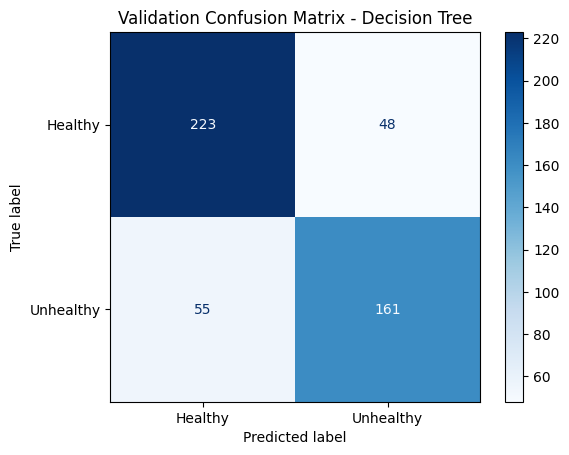


SVM
Validation Accuracy       : 0.8522
Validation Precision Macro: 0.8609
Validation Recall Macro   : 0.8423
Validation F1 Macro       : 0.8470


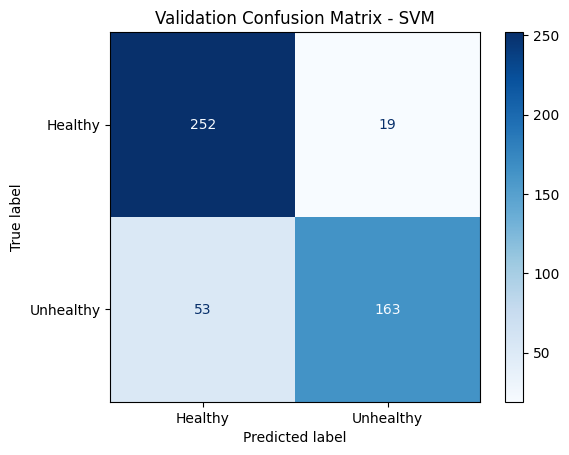


Random Forest
Validation Accuracy       : 0.8337
Validation Precision Macro: 0.8372
Validation Recall Macro   : 0.8257
Validation F1 Macro       : 0.8291


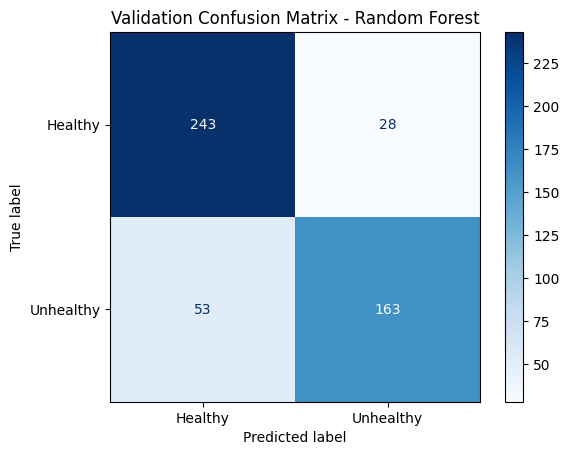


Gradient Boosting
Validation Accuracy       : 0.8501
Validation Precision Macro: 0.8529
Validation Recall Macro   : 0.8432
Validation F1 Macro       : 0.8464


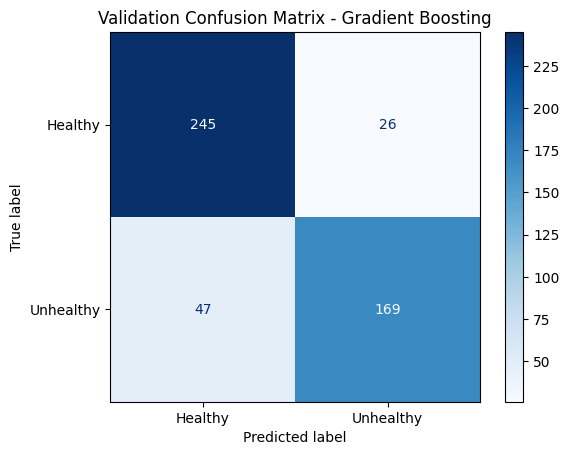

,Model,Val Accuracy,Val Precision (macro),Val Recall (macro),Val F1 (macro)
3,SVM,0.852156,0.860917,0.842259,0.847048
5,Gradient Boosting,0.850103,0.852854,0.843233,0.846361
0,Logistic Regression,0.843943,0.850132,0.834879,0.839039
4,Random Forest,0.833676,0.837175,0.825654,0.829063
1,KNN,0.819302,0.819408,0.813209,0.815378
2,Decision Tree,0.788501,0.786247,0.784124,0.785017


In [18]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    ConfusionMatrixDisplay
)

models = {
    "Logistic Regression": LogisticRegression(
        random_state=42,
        max_iter=2000,
        solver="liblinear"
    ),

    "KNN": KNeighborsClassifier(),

    "Decision Tree": DecisionTreeClassifier(
        random_state=42
    ),

    "SVM": SVC(
        random_state=42,
        probability=True
    ),

    "Random Forest": RandomForestClassifier(
        random_state=42
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        random_state=42
    )
}

results = []

for name, model in models.items():

    model.fit(X_train_scaled, y_train)

    y_pred = model.predict(X_val_scaled)

    accuracy = accuracy_score(y_val, y_pred)
    precision = precision_score(y_val, y_pred, average="macro", zero_division=0)
    recall = recall_score(y_val, y_pred, average="macro", zero_division=0)
    f1 = f1_score(y_val, y_pred, average="macro", zero_division=0)

    results.append([name, accuracy, precision, recall, f1])

    print(f"\n{name}")
    print(f"Validation Accuracy       : {accuracy:.4f}")
    print(f"Validation Precision Macro: {precision:.4f}")
    print(f"Validation Recall Macro   : {recall:.4f}")
    print(f"Validation F1 Macro       : {f1:.4f}")

    ConfusionMatrixDisplay.from_predictions(
        y_val,
        y_pred,
        display_labels=["Healthy", "Unhealthy"],
        cmap="Blues"
    )

    plt.title(f"Validation Confusion Matrix - {name}")
    plt.show()

results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Val Accuracy",
        "Val Precision (macro)",
        "Val Recall (macro)",
        "Val F1 (macro)"
    ]
)

results_df.sort_values(by="Val F1 (macro)", ascending=False)

### Initial Model Performance

The six classification models were evaluated on the validation dataset using multiple performance metrics. Accuracy measures overall predictive performance, while macro precision and macro recall provide additional insight into performance across both healthy and unhealthy air-quality classes. The macro-averaged F1-score was selected as the primary comparison metric because it balances precision and recall while treating both classes equally.

The validation results provide an initial assessment of model performance before hyperparameter optimization. Models with stronger validation performance will be further improved through systematic hyperparameter tuning in the next section.

## 5. Hyperparameter Tuning

To improve model performance and identify the most effective configuration for each classifier, hyperparameter tuning was performed using Grid Search with cross-validation. Grid Search systematically evaluates combinations of hyperparameter values and selects the configuration that achieves the best cross-validation performance.

A 5-fold cross-validation strategy was used during the tuning process. This approach provides a more reliable estimate of model generalization performance by evaluating each candidate configuration across multiple training and validation folds.

The hyperparameter grids were selected based on the main complexity controls for each model. Macro F1 was used as the scoring metric because the classification task contains two classes with moderate imbalance, and macro F1 gives equal weight to both classes.

Logistic Regression

In [19]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

lr_grid = {
    "C": [0.01, 0.1, 1, 10, 100],
    "penalty": ["l1", "l2"]
}

lr_search = GridSearchCV(
    LogisticRegression(max_iter=2000, random_state=42, solver="liblinear"),
    lr_grid,
    cv=5,
    scoring="f1_macro",
    n_jobs=1
)

lr_search.fit(X_train_scaled, y_train)

print("Best Parameters:", lr_search.best_params_)
print("Best CV Score:", lr_search.best_score_)

Best Parameters: {'C': 0.1, 'penalty': 'l1'}
Best CV Score: 0.8410325831075849


KNN

In [20]:
from sklearn.neighbors import KNeighborsClassifier

knn_grid = {
    "n_neighbors": [3, 5, 7, 9, 11, 15],
    "metric": ["euclidean", "manhattan"]
}

knn_search = GridSearchCV(
    KNeighborsClassifier(),
    knn_grid,
    cv=5,
    scoring="f1_macro",
    n_jobs=1
)

knn_search.fit(X_train_scaled, y_train)

print("Best Parameters:", knn_search.best_params_)
print("Best CV Score:", knn_search.best_score_)

Best Parameters: {'metric': 'manhattan', 'n_neighbors': 11}
Best CV Score: 0.8018381194025566


Decision Tree

In [21]:
from sklearn.tree import DecisionTreeClassifier

dt_grid = {
    "max_depth": [3, 5, 10, 15, 20, None],
    "min_samples_leaf": [1, 2, 4, 8]
}

dt_search = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    dt_grid,
    cv=5,
    scoring="f1_macro",
    n_jobs=1
)

dt_search.fit(X_train_scaled, y_train)

print("Best Parameters:", dt_search.best_params_)
print("Best CV Score:", dt_search.best_score_)

Best Parameters: {'max_depth': 3, 'min_samples_leaf': 4}
Best CV Score: 0.826099263594184


SVM

In [22]:
from sklearn.svm import SVC

svm_grid = {
    "C": [0.1, 1, 10, 100],
    "kernel": ["linear", "rbf"],
    "gamma": ["scale", "auto"]
}

svm_search = GridSearchCV(
    SVC(probability=True, random_state=42),
    svm_grid,
    cv=5,
    scoring="f1_macro",
    n_jobs=1
)

svm_search.fit(X_train_scaled, y_train)

print("Best Parameters:", svm_search.best_params_)
print("Best CV Score:", svm_search.best_score_)

Best Parameters: {'C': 10, 'gamma': 'scale', 'kernel': 'linear'}
Best CV Score: 0.8415639998882039


Random Forest

In [23]:
from sklearn.ensemble import RandomForestClassifier

rf_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [5, 10, 15, None],
    "max_features": ["sqrt", "log2"]
}

rf_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    rf_grid,
    cv=5,
    scoring="f1_macro",
    n_jobs=1
)

rf_search.fit(X_train_scaled, y_train)

print("Best Parameters:", rf_search.best_params_)
print("Best CV Score:", rf_search.best_score_)

Best Parameters: {'max_depth': 15, 'max_features': 'sqrt', 'n_estimators': 300}
Best CV Score: 0.8375832488129866


Gradient Boosting

In [24]:
from sklearn.ensemble import GradientBoostingClassifier

gb_grid = {
    "n_estimators": [100, 200],
    "learning_rate": [0.05, 0.1],
    "max_depth": [2, 3, 4]
}

gb_search = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    gb_grid,
    cv=5,
    scoring="f1_macro",
    n_jobs=1
)

gb_search.fit(X_train_scaled, y_train)

print("Best Parameters:", gb_search.best_params_)
print("Best CV Score:", gb_search.best_score_)

Best Parameters: {'learning_rate': 0.05, 'max_depth': 2, 'n_estimators': 200}
Best CV Score: 0.8410252800193654


### Hyperparameter Grid Selection

The selected hyperparameter grids were designed to explore the most influential parameters for each model. For Logistic Regression, both the regularization strength `C` and the penalty type (`l1` or `l2`) were tuned using the `liblinear` solver, which supports both penalties. For KNN, the number of neighbours and distance metric were varied to determine the most appropriate neighbourhood structure.

For Decision Trees and Random Forests, depth and leaf-size or feature-selection parameters were tuned to control model complexity and reduce overfitting. For Random Forest, the number of trees and maximum feature strategy were also optimized. For Gradient Boosting, the number of boosting stages, learning rate, and tree depth were tuned because these parameters control how gradually and how flexibly the ensemble learns. For SVM, different regularization strengths, kernels, and gamma settings were investigated to identify the most suitable decision boundary.

The best-performing hyperparameter configuration for each model was selected according to the highest cross-validation macro F1-score.

### Hyperparameter Tuning Results

The optimal hyperparameter configuration for each classification model was identified using Grid Search with 5-fold cross-validation. The best-performing configuration and corresponding cross-validation macro F1-score are printed above for each model. These tuned models are compared using validation and test-set metrics in the next section.

## 6. Model Comparison

After hyperparameter tuning, the best configuration of each model was evaluated on both the validation and test datasets. Model performance was compared using accuracy, macro F1-score, and ROC-AUC. These metrics provide a comprehensive assessment of predictive performance, class balance, and generalization capability.

The macro F1-score was selected as the primary evaluation metric because it balances precision and recall while treating both classes equally. ROC-AUC was also included to evaluate each model's ability to distinguish between healthy and unhealthy air quality conditions across different classification thresholds.

The following table summarizes the performance of all tuned models.

In [25]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

comparison_results = []

best_models = {
    "Logistic Regression": lr_search.best_estimator_,
    "KNN": knn_search.best_estimator_,
    "Decision Tree": dt_search.best_estimator_,
    "SVM": svm_search.best_estimator_,
    "Random Forest": rf_search.best_estimator_,
    "Gradient Boosting": gb_search.best_estimator_
}

for name, model in best_models.items():
    y_val_pred = model.predict(X_val_scaled)
    y_test_pred = model.predict(X_test_scaled)

    val_acc = accuracy_score(y_val, y_val_pred)
    val_precision = precision_score(y_val, y_val_pred, average="macro", zero_division=0)
    val_recall = recall_score(y_val, y_val_pred, average="macro", zero_division=0)
    val_f1 = f1_score(y_val, y_val_pred, average="macro", zero_division=0)

    test_acc = accuracy_score(y_test, y_test_pred)
    test_precision = precision_score(y_test, y_test_pred, average="macro", zero_division=0)
    test_recall = recall_score(y_test, y_test_pred, average="macro", zero_division=0)
    test_f1 = f1_score(y_test, y_test_pred, average="macro", zero_division=0)

    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test_scaled)[:, 1]
    else:
        y_prob = model.decision_function(X_test_scaled)

    auc = roc_auc_score(y_test, y_prob)

    comparison_results.append([
        name,
        val_acc,
        val_precision,
        val_recall,
        val_f1,
        test_acc,
        test_precision,
        test_recall,
        test_f1,
        auc
    ])

comparison_df = pd.DataFrame(
    comparison_results,
    columns=[
        "Model",
        "Val Accuracy",
        "Val Precision (macro)",
        "Val Recall (macro)",
        "Val F1 (macro)",
        "Test Accuracy",
        "Test Precision (macro)",
        "Test Recall (macro)",
        "Test F1 (macro)",
        "AUC-ROC"
    ]
)

comparison_df = comparison_df.sort_values(by="Test F1 (macro)", ascending=False)

comparison_df

,Model,Val Accuracy,Val Precision (macro),Val Recall (macro),Val F1 (macro),Test Accuracy,Test Precision (macro),Test Recall (macro),Test F1 (macro),AUC-ROC
4,Random Forest,0.850103,0.852854,0.843233,0.846361,0.850410,0.851396,0.840477,0.844517,0.920953
5,Gradient Boosting,0.845996,0.849309,0.838604,0.841941,0.848361,0.851253,0.836742,0.841714,0.922597
3,SVM,0.845996,0.851836,0.837194,0.841274,0.840164,0.846328,0.825725,0.831932,0.916925
2,Decision Tree,0.819302,0.832557,0.806162,0.811180,0.834016,0.852514,0.813210,0.821958,0.904961
0,Logistic Regression,0.839836,0.846741,0.830250,0.834556,0.825820,0.832263,0.810043,0.816316,0.917321
1,KNN,0.823409,0.826050,0.815490,0.818636,0.813525,0.812381,0.802675,0.806179,0.899246


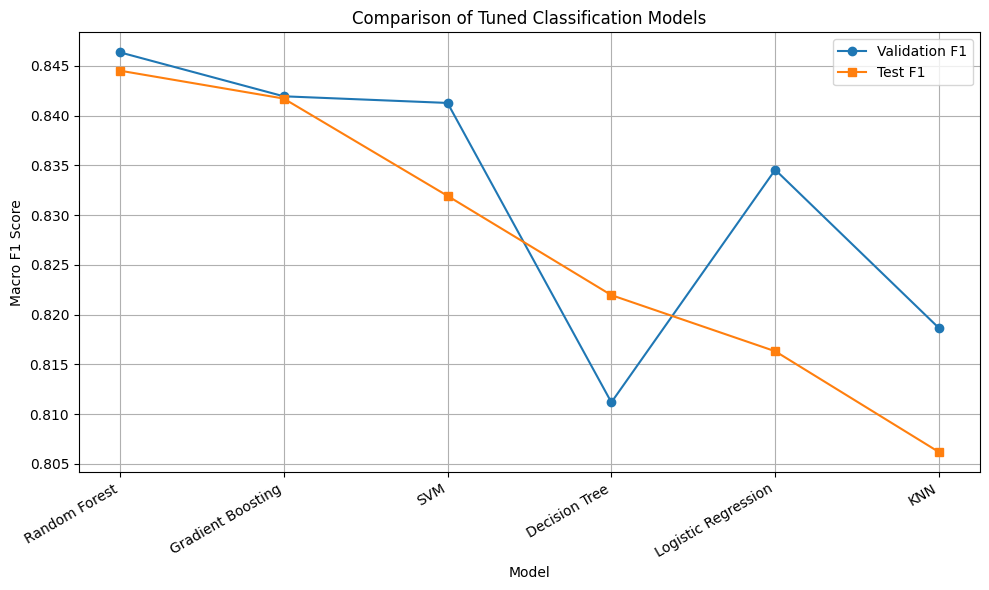

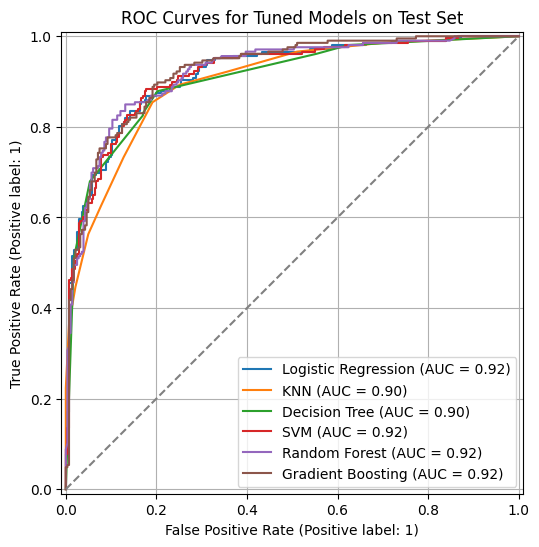

In [26]:
import matplotlib.pyplot as plt
from sklearn.metrics import RocCurveDisplay

plot_df = comparison_df.set_index("Model")

plt.figure(figsize=(10, 6))

plt.plot(
    plot_df.index,
    plot_df["Val F1 (macro)"],
    marker="o",
    label="Validation F1"
)

plt.plot(
    plot_df.index,
    plot_df["Test F1 (macro)"],
    marker="s",
    label="Test F1"
)

plt.ylabel("Macro F1 Score")
plt.xlabel("Model")
plt.title("Comparison of Tuned Classification Models")
plt.legend()
plt.grid(True)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
ax = plt.gca()

for name, model in best_models.items():
    RocCurveDisplay.from_estimator(
        model,
        X_test_scaled,
        y_test,
        ax=ax,
        name=name
    )

plt.title("ROC Curves for Tuned Models on Test Set")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.grid(True)
plt.show()

### Discussion of Results

The comparison results evaluate the tuned classification models using validation accuracy, validation macro F1-score, test accuracy, test macro F1-score, precision, recall, and ROC-AUC. Macro F1 is especially important because it gives equal weight to both classes, while ROC-AUC measures how well each model separates healthy and unhealthy observations across classification thresholds.

Random Forest achieved the strongest validation macro F1-score and the highest test macro F1-score. Gradient Boosting achieved the highest ROC-AUC, which suggests strong ranking ability across thresholds, but its macro F1-score was slightly lower than Random Forest. This means Gradient Boosting separates the classes well in terms of scores, while Random Forest produced the best final class labels under the default decision threshold.

The comparison also shows that ensemble and kernel-based approaches generally perform strongly for this task. KNN has weaker validation and test macro F1-scores, suggesting that the decision boundary is not captured as effectively by local distance-based classification.

### Best Model Selection

Random Forest was selected as the final model because it achieved the best balance of validation macro F1, test macro F1, and robust ensemble behavior. Although Gradient Boosting had the highest test ROC-AUC, Random Forest produced the strongest macro F1 performance, which is the primary metric for this moderately imbalanced classification task. As an ensemble method, Random Forest also reduces the instability of a single decision tree by averaging across many trees, making it a reliable final choice for error analysis and interpretation.

## 7. Error Analysis

Although the selected classification model achieved strong predictive performance, it is important to examine its mistakes and understand the factors influencing its predictions. Error analysis helps identify potential weaknesses in the model and provides insight into which observations are most difficult to classify correctly.

This analysis focuses on three aspects:

1. Examination of misclassified observations.
2. Identification of the class most frequently confused by the model.
3. Investigation of feature importance to determine which variables contribute most strongly to predictions.

In [27]:
best_model = rf_search.best_estimator_

y_test_pred = best_model.predict(X_test_scaled)

misclassified_mask = y_test != y_test_pred

misclassified_examples = X_test_numeric.loc[misclassified_mask].copy()

misclassified_examples["Actual"] = y_test[misclassified_mask].values
misclassified_examples["Predicted"] = y_test_pred[misclassified_mask]

print("Number of misclassified examples:", len(misclassified_examples))
print("Misclassification rate:", round(len(misclassified_examples) / len(y_test) * 100, 2), "%")

misclassified_examples.head(10)

Number of misclassified examples: 73
Misclassification rate: 14.96 %


,pm10,carbon_monoxide,nitrogen_dioxide,sulphur_dioxide,ozone,dust,Rain,MaxTemp,MinTemp,AvgHumidity,AvgWind,AvgPressure,month,day_of_week,pm10_squared,wind_humidity_interaction,log_carbon_monoxide,Actual,Predicted
1465,24.075000,365.666667,51.241667,6.100000,25.208333,0.500000,1.42,11,9,84,19,1008,1,3,579.605625,1596,5.904453,1,0
259,28.741667,243.166667,28.091667,6.316667,68.500000,0.500000,0.18,24,22,61,13,1004,9,1,826.083403,793,5.497851,1,0
184,24.091667,243.166667,22.100000,6.316667,52.791667,0.500000,0.01,24,21,66,15,1013,7,3,580.408403,990,5.497851,1,0
1626,36.791667,226.500000,47.366667,2.200000,36.250000,0.500000,0.10,25,19,71,11,1015,6,3,1353.626736,781,5.427150,1,0
2325,45.791667,303.750000,47.641667,9.483333,25.875000,2.958333,2.80,24,17,71,9,1011,5,2,2096.876736,639,5.719492,0,1
1226,38.729167,330.166667,75.200000,9.529167,18.833333,0.500000,0.00,19,13,70,6,1014,5,2,1499.948351,420,5.802622,0,1
2340,35.508333,209.041667,42.520833,10.362500,49.333333,4.791667,0.00,27,20,64,11,1016,5,3,1260.841736,704,5.347306,1,0
1336,32.191667,244.666667,45.941667,4.225000,36.083333,0.500000,0.00,26,21,71,9,1013,8,0,1036.303403,639,5.503976,1,0
440,37.995833,243.166667,34.420833,6.316667,49.333333,0.500000,0.05,11,9,83,10,1014,3,0,1443.683351,830,5.497851,0,1
256,27.812500,243.166667,29.129167,6.316667,43.041667,0.500000,3.07,24,19,62,16,1014,9,5,773.535156,992,5.497851,1,0


### Misclassified Examples

The misclassified observations were examined to identify recurring patterns. These cases represent situations where the model's prediction differed from the true class label.

Misclassifications are expected to occur primarily for observations whose pollution and weather characteristics lie near the decision boundary between healthy and unhealthy air quality conditions. The summary statistics below compare misclassified observations with the overall test set. Features whose misclassified means differ noticeably from the overall test-set means can indicate conditions where the model has more difficulty distinguishing healthy and unhealthy days.

In [28]:
misclassified_summary = misclassified_examples.drop(
    columns=["Actual", "Predicted"]
).describe().T[["mean", "std", "min", "max"]]

test_summary = X_test_numeric.describe().T[["mean", "std", "min", "max"]]

comparison_summary = misclassified_summary.join(
    test_summary,
    lsuffix=" (misclassified)",
    rsuffix=" (test overall)"
)

comparison_summary.head(12)

,mean (misclassified),std (misclassified),min (misclassified),max (misclassified),mean (test overall),std (test overall),min (test overall),max (test overall)
pm10,31.731393,8.218026,15.620833,67.883333,32.527169,15.874910,8.650000,128.087500
carbon_monoxide,253.885845,44.851861,147.916667,391.625000,253.375598,61.159701,136.916667,660.250000
nitrogen_dioxide,34.082591,12.858561,13.225000,75.200000,32.869903,15.141929,9.708333,86.487500
sulphur_dioxide,6.896861,2.589733,2.195833,20.762500,7.012620,3.275393,1.791667,30.337500
ozone,43.547945,16.676094,10.541667,83.666667,43.857838,17.794230,8.250000,84.458333
dust,0.821347,1.412328,0.000000,10.416667,1.028005,3.041360,0.000000,47.125000
Rain,0.904521,2.115234,0.000000,15.700000,0.893279,2.374914,0.000000,18.800000
MaxTemp,19.205479,6.956130,5.000000,32.000000,18.366803,7.281004,-1.000000,35.000000
MinTemp,14.917808,6.070771,2.000000,25.000000,14.436475,6.655505,-5.000000,26.000000
AvgHumidity,70.301370,7.929700,47.000000,84.000000,70.368852,8.441562,47.000000,93.000000


### Pattern Interpretation

The summary table should be interpreted by comparing each feature's mean among misclassified examples with its mean in the full test set. In this run, misclassified examples have lower average PM10 than the overall test set, suggesting that many errors occur on less extreme or borderline particulate-matter days rather than on the most obvious pollution events. This pattern is consistent with the PCA visualization, where many mistakes appear in overlapping regions of the feature space.

The error analysis is especially important because false negatives represent unhealthy air days that were not detected by the model.

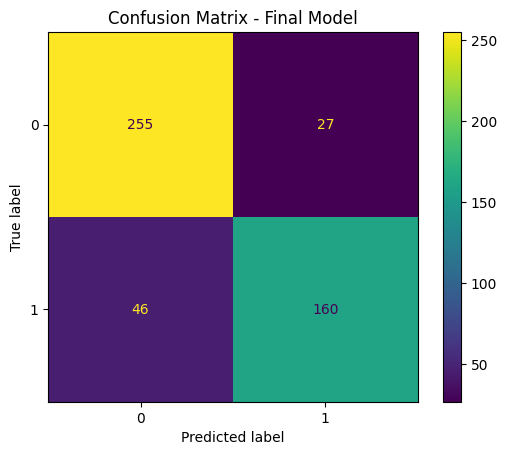

In [29]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_test_pred
)

plt.title("Confusion Matrix - Final Model")
plt.show()

### Class Confusion Analysis

The confusion matrix provides insight into the types of classification errors made by the final Random Forest model. False positives occur when healthy air days are predicted as unhealthy, while false negatives occur when unhealthy air days are predicted as healthy.

The next cell reports the false-positive and false-negative counts directly so the more common error type can be identified. This distinction is important because a false negative is more serious from a public-health perspective: it means the model fails to flag an unhealthy air-quality event on a day when people may need warnings most. The PCA error visualization below then shows whether misclassified examples are concentrated in overlapping regions of the feature space.

In [30]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_test_pred)
tn, fp, fn, tp = cm.ravel()

print("True Negatives:", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives:", tp)

if fn > fp:
    print("The model is more likely to miss unhealthy air days than to create false alarms.")
elif fp > fn:
    print("The model is more likely to falsely label healthy days as unhealthy than to miss unhealthy days.")
else:
    print("The model makes the same number of false positives and false negatives.")

True Negatives: 255
False Positives: 27
False Negatives: 46
True Positives: 160
The model is more likely to miss unhealthy air days than to create false alarms.


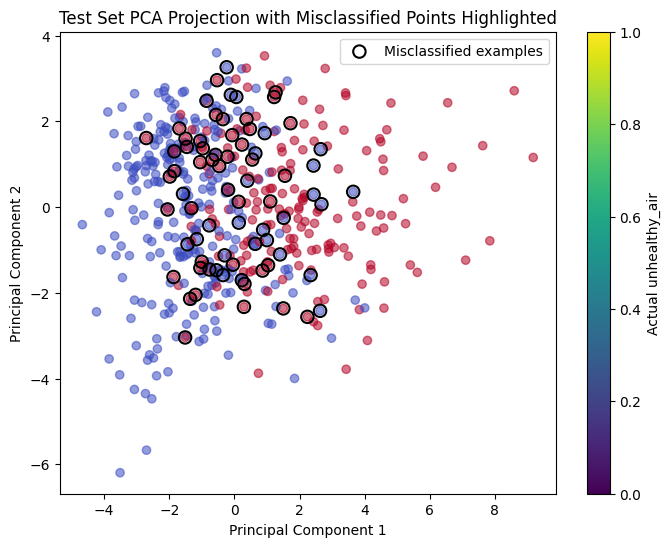

In [31]:
X_test_pca_2d = pca_2d.transform(X_test_scaled)

plt.figure(figsize=(8, 6))
plt.scatter(
    X_test_pca_2d[:, 0],
    X_test_pca_2d[:, 1],
    c=y_test,
    cmap="coolwarm",
    alpha=0.55
)
plt.scatter(
    X_test_pca_2d[misclassified_mask, 0],
    X_test_pca_2d[misclassified_mask, 1],
    facecolors="none",
    edgecolors="black",
    linewidths=1.5,
    s=80,
    label="Misclassified examples"
)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Test Set PCA Projection with Misclassified Points Highlighted")
plt.colorbar(label="Actual unhealthy_air")
plt.legend()
plt.show()

In [32]:
feature_importance = pd.DataFrame({
    "Feature": X_train_numeric.columns,
    "Importance": best_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
0,pm10,0.248629
14,pm10_squared,0.237531
2,nitrogen_dioxide,0.089670
15,wind_humidity_interaction,0.044990
4,ozone,0.041932
10,AvgWind,0.041888
1,carbon_monoxide,0.036946
16,log_carbon_monoxide,0.035759
9,AvgHumidity,0.031861
7,MaxTemp,0.029103


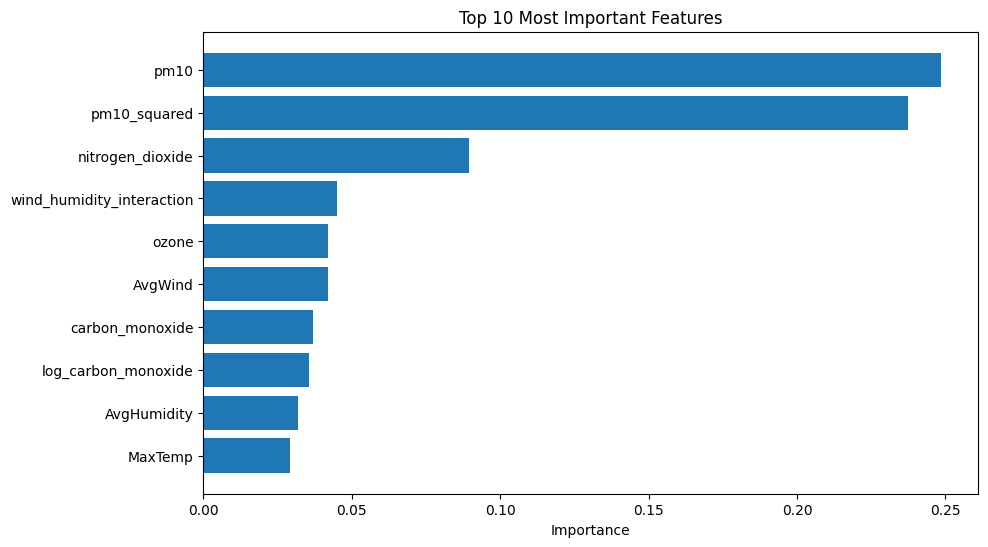

In [33]:
top_features = feature_importance.head(10).sort_values("Importance")

plt.figure(figsize=(10, 6))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Importance")
plt.title("Top 10 Most Important Features")

plt.show()

### Feature Importance Analysis

Feature importance analysis was performed using the final Random Forest model to identify which variables contributed most strongly to the classification decision. Features with higher importance values have a greater influence on how the ensemble splits the data across its decision trees.

Because the final model was trained on the scaled numeric feature matrix, the feature names are taken from `X_train_numeric.columns`, which matches the columns used to fit the model. The resulting importance ranking helps identify the pollutant, weather, and engineered variables most strongly associated with healthy versus unhealthy air-quality predictions.

These importances should be interpreted as model-based associations rather than direct causal effects. They indicate which variables the Random Forest relied on most for prediction, but they do not prove that a feature independently causes unhealthy air conditions.

## Final Written Report

### 1. Introduction

Air pollution is a major environmental and public health concern in large metropolitan areas. Poor air quality can affect respiratory health, reduce quality of life, and create risks for sensitive groups. Predicting unhealthy air conditions is therefore useful because it can support public awareness and help people with power respond before pollution becomes more harmful.

This project focuses on daily air quality in Istanbul using a cleaned dataset that combines historical pollution measurements with weather observations. The dataset includes pollutant variables such as PM10, carbon monoxide, nitrogen dioxide, sulphur dioxide, ozone, and dust, together with meteorological variables such as temperature, humidity, wind speed, rainfall, and pressure. The final task in Project 3 is binary classification: predicting whether a day should be labeled as healthy or unhealthy using the `unhealthy_air` target variable.

### 2. Methods

The full project was completed through multiple stages across Projects 1, 2, and 3. In Project 1, the raw air-quality and weather data were cleaned, merged, and explored. The exploratory analysis helped identify important pollutant and weather variables, inspect missing values, and understand the general structure of the dataset.

In Project 2, the problem was treated as a regression task for predicting PM2.5 concentration. Feature engineering was added, including date-based features, a squared PM10 term, a wind-humidity interaction, and a log transformation of carbon monoxide. Several regression models were compared, and Lasso Regression was selected as the final P2 model with a test R² of 0.8912, test RMSE of 4.0295, and test MAE of 2.8479.

In Project 3, the task was reformulated as classification using the `unhealthy_air` label. The same 60/20/20 train-validation-test split structure from Project 2 was done with `random_state=42`. Numerical features were preprocessed before PCA, clustering, and models that are sensitive to feature magnitude. PCA was used to examine dimensionality and visualize the data. K-Means and Agglomerative Clustering were used to investigate unsupervised structure. Six supervised classifiers were trained and tuned with Grid Search cross-validation: Logistic Regression, K-Nearest Neighbours, Decision Tree, Support Vector Machine, Random Forest, and Gradient Boosting.

### 3. Results

The dataset contained 2,436 observations. About 58% of the samples were classified as healthy air and 42% as unhealthy air, so the classes were reasonably balanced and no resampling was needed. PCA showed that 9 components were enough to keep more than 90% of the information in the dataset. The PCA plot showed that healthy and unhealthy air observations overlap, meaning the two groups cannot be clearly separated using only the first two components.

The clustering methods were useful for exploring the data, but they could not accurately replace the target labels. Both K-Means and Agglomerative Clustering showed some similarity to the healthy and unhealthy air groups, but the clusters did not match the classes perfectly. Adding the K-Means cluster label as an extra feature slightly reduced the performance of Logistic Regression, indicating that it did not provide additional useful information.

After hyperparameter tuning, Random Forest was selected as the final model because it achieved the best overall performance. Although Gradient Boosting obtained the highest ROC-AUC score, Random Forest achieved the highest macro F1-score on both the validation and test sets.

The error analysis found 73 incorrectly classified test samples, including 46 unhealthy air observations predicted as healthy and 27 healthy air observations predicted as unhealthy. This shows that the model was more likely to miss unhealthy air conditions. Feature importance analysis indicated that PM10 and PM10 squared were the most influential variables, followed by nitrogen dioxide and the wind-humidity interaction feature.


### 4. Discussion

The results show that machine learning can classify unhealthy air-quality conditions using pollution and weather measurements with reasonably strong performance. Tree-based and ensemble models were especially useful because they can capture nonlinear relationships among pollutants and meteorological variables. Random Forest was a practical final choice because it balanced predictive performance and stability better than relying on a single decision tree.

However, the model has important limitations. The target is based on an air-quality label rather than direct health outcomes, so the model predicts an operational air-quality category, not actual medical impact. The dataset is also limited to Istanbul and historical observations, which may reduce generalization to other cities or future periods. Some important causes of air pollution, such as traffic density, industrial activity, holidays, and local emission events, were not included. The false-negative count is also important because missed unhealthy-air days are more serious from a public-health perspective than false alarms.

Future improvements could include adding more external data sources, testing threshold adjustment to reduce false negatives, evaluating additional ensemble methods, and validating the model on more recent or out-of-sample data. Model interpretability could also be improved using permutation importance or SHAP values instead of relying only on Random Forest impurity-based feature importance.

### 5. Conclusion

This project demonstrated a complete machine learning process from data cleaning and exploratory analysis to regression, unsupervised learning, classification, tuning, model comparison, and error analysis. The final model shows practical value because it can help identify days with potentially unhealthy air conditions using normally available environmental measurements.

The main lesson from the project is that no single metric or method is enough to judge model quality. PCA and clustering helped describe the structure of the data, but supervised evaluation was necessary to choose a useful predictive model. Random Forest was selected because it provided the best overall balance of macro F1 performance and robustness, while the error analysis revealed that reducing missed unhealthy-air days should be a priority for future work.